# Restaurant Revenue Prediction

### Imports

In [98]:
import os
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import zipfile
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

### Data

In [99]:
print("Please upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c restaurant-revenue-prediction

!unzip -o restaurant-revenue-prediction.zip

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
restaurant-revenue-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  restaurant-revenue-prediction.zip
  inflating: sampleSubmission.csv    
  inflating: test.csv.zip            
  inflating: train.csv.zip           


In [100]:
for file_name in os.listdir('.'):
    if file_name.endswith('.csv.zip'):
        with zipfile.ZipFile(file_name, 'r') as zip_ref:
            zip_ref.extractall('.')
            print(f"Extracted {file_name}")

df = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

df.head()

Extracted train.csv.zip
Extracted test.csv.zip


,Id,Open Date,City,City Group,Type,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,...,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,revenue
0,0,07/17/1999,İstanbul,Big Cities,IL,4,5.0,4.0,4.0,2,2,5,4,5,5,3,...,3,1,1,1.0,4.0,2.0,3.0,5,3,4,5,5,4,3,4,5653753.0
1,1,02/14/2008,Ankara,Big Cities,FC,4,5.0,4.0,4.0,1,2,5,5,5,5,1,...,2,0,0,0.0,0.0,3.0,3.0,0,0,0,0,0,0,0,0,6923131.0
2,2,03/09/2013,Diyarbakır,Other,IL,2,4.0,2.0,5.0,2,3,5,5,5,5,2,...,1,0,0,0.0,0.0,1.0,3.0,0,0,0,0,0,0,0,0,2055379.0
3,3,02/02/2012,Tokat,Other,IL,6,4.5,6.0,6.0,4,4,10,8,10,10,8,...,10,2,2,2.5,2.5,2.5,7.5,25,12,10,6,18,12,12,6,2675511.0
4,4,05/09/2009,Gaziantep,Other,IL,3,4.0,3.0,4.0,2,2,5,5,5,5,2,...,1,2,3,3.0,5.0,1.0,3.0,5,1,3,2,3,4,3,3,4316715.0


### Dataset exploration

In [101]:
print('Train:', df.shape)
print('Test:', df_test.shape)

Train: (137, 43)
Test: (100000, 42)


In [102]:
df.sort_values(ascending=False, by='revenue').head(25)

,Id,Open Date,City,City Group,Type,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,...,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,revenue
16,16,01/07/2000,İstanbul,Big Cities,FC,3,5.0,4.0,4.0,2,5,5,4,5,4,3,...,1,0,0,0.0,0.0,2.0,2.0,0,0,0,0,0,0,0,0,19696939.0
75,75,10/15/2005,İstanbul,Big Cities,FC,5,5.0,4.0,5.0,1,4,5,3,4,4,5,...,4,0,0,0.0,0.0,5.0,0.0,0,0,0,0,0,0,0,0,16549064.0
99,99,12/18/1999,İstanbul,Big Cities,IL,4,5.0,4.0,4.0,2,4,5,4,4,4,5,...,1,5,5,5.0,1.0,5.0,1.0,5,5,4,2,5,5,5,3,13575224.0
100,100,09/21/2007,İstanbul,Big Cities,FC,3,5.0,4.0,4.0,2,5,5,5,5,5,2,...,1,0,0,0.0,0.0,4.0,3.0,0,0,0,0,0,0,0,0,9652350.0
133,133,10/12/2006,İzmir,Big Cities,FC,4,5.0,4.0,4.0,2,3,5,4,4,5,5,...,1,0,0,0.0,0.0,3.0,3.0,0,0,0,0,0,0,0,0,9262754.0
24,24,09/20/2009,İstanbul,Big Cities,IL,5,5.0,3.0,5.0,2,2,5,5,5,4,2,...,3,2,2,2.0,5.0,3.0,2.0,5,5,4,4,4,4,5,2,8904084.0
116,116,03/30/2012,İzmir,Big Cities,FC,2,4.0,4.0,4.0,2,2,5,4,4,5,3,...,1,0,0,0.0,0.0,3.0,3.0,0,0,0,0,0,0,0,0,8894598.0
49,49,04/01/2008,İstanbul,Big Cities,FC,12,7.5,6.0,6.0,2,8,10,10,10,10,4,...,5,0,0,0.0,0.0,7.5,7.5,0,0,0,0,0,0,0,0,8630682.0
17,17,11/08/2009,İstanbul,Big Cities,FC,2,4.0,4.0,5.0,1,3,5,4,5,5,3,...,1,0,0,0.0,0.0,1.0,1.0,0,0,0,0,0,0,0,0,8213524.0
47,47,12/23/2009,İzmir,Big Cities,IL,4,5.0,5.0,3.0,1,2,5,4,5,5,3,...,5,4,4,4.0,4.0,5.0,3.0,4,1,2,2,3,5,5,1,7865428.0


In [103]:
df.sort_values(ascending=False, by='revenue').tail(25)

,Id,Open Date,City,City Group,Type,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,...,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,revenue
72,72,08/05/2009,İzmir,Big Cities,IL,3,5.0,4.0,4.0,2,2,5,3,4,5,5,...,5,5,2,5.0,3.0,5.0,1.0,4,3,3,2,3,4,3,1,2525375.0
56,56,03/16/2013,İstanbul,Big Cities,IL,4,5.0,4.0,4.0,2,2,5,4,4,4,5,...,2,0,0,0.0,0.0,3.0,3.0,0,0,0,0,0,0,0,0,2390534.0
128,128,10/14/2011,Ankara,Big Cities,FC,2,4.0,4.0,4.0,1,2,5,5,5,5,1,...,1,0,0,0.0,0.0,3.0,2.0,0,0,0,0,0,0,0,0,2383840.0
33,33,04/23/2013,Samsun,Other,FC,2,3.0,4.0,4.0,2,2,5,5,5,5,1,...,1,0,0,0.0,0.0,2.0,3.0,0,0,0,0,0,0,0,0,2371202.0
89,89,05/11/2009,İstanbul,Big Cities,IL,1,1.0,4.0,3.0,1,2,1,5,5,5,1,...,1,1,1,1.0,5.0,1.0,3.0,5,4,4,3,3,4,2,3,2364478.0
98,98,03/11/2011,Denizli,Other,FC,3,4.0,4.0,4.0,1,2,5,2,4,5,5,...,1,0,0,0.0,0.0,2.0,3.0,0,0,0,0,0,0,0,0,2344689.0
26,26,02/23/2010,Ankara,Big Cities,IL,3,5.0,4.0,5.0,2,3,5,3,5,4,5,...,2,2,2,2.0,1.0,3.0,3.0,5,5,4,3,3,4,3,1,2267425.0
50,50,05/01/2010,Ankara,Big Cities,IL,3,5.0,4.0,5.0,3,4,5,4,4,4,5,...,2,2,2,2.0,1.0,3.0,3.0,5,2,3,2,2,2,3,3,2156098.0
113,113,12/09/2006,Tekirdağ,Other,FC,3,4.0,4.0,4.0,1,2,5,5,5,5,2,...,1,0,0,0.0,0.0,2.0,2.0,0,0,0,0,0,0,0,0,2097022.0
91,91,06/20/2007,Bursa,Other,IL,3,5.0,4.0,4.0,1,2,5,5,5,5,1,...,2,0,0,0.0,0.0,1.0,3.0,0,0,0,0,0,0,0,0,2083447.0


# Analisis I

**Anotacions**

1.   No tinc informació de que es cada variable
2.   Algunes entrades tenen molts valors a 0, son 0 o missings?
3.   La revenue no esta en diners, ja ha patit una transformació
4.   Un dels tipus de restaurants nomes te una entrada en tot el dataset de train

**Estrategia**

1.   Fittejar un model cutre
2.   Intentar entendre el dataset a base del pesos del model


 ### XGBoost

In [104]:
def data_preparation(df):
    df_train = df.copy()
    df_train['Type'] = df_train['Type'].astype('category').cat.codes
    # df_train['City'] = df_train['City'].astype('category').cat.codes
    df_train['City Group'] = df_train['City Group'].astype('category').cat.codes

    city_means = df_train.groupby('City')['revenue'].mean()
    df_train['City_Encoded'] = df_train['City'].map(city_means)

    # type_means = df_train.groupby('Type')['revenue'].mean()
    # df_train['Type_Encoded'] = df_train['Type'].map(type_means)

    drop_cols = ['Id', 'Open Date', 'City']
    df_train = df_train.drop(columns=[c for c in drop_cols if c in df.columns])
    return df_train

df_processed = data_preparation(df)

X = df_processed.drop(columns=['revenue'])
y = df_processed['revenue']

model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X, y)

y_pred = model.predict(X)
rmse = root_mean_squared_error(y, y_pred)

print(f"RMSE XGBoost I: {rmse}")

RMSE XGBoost I: 1095639.713055124


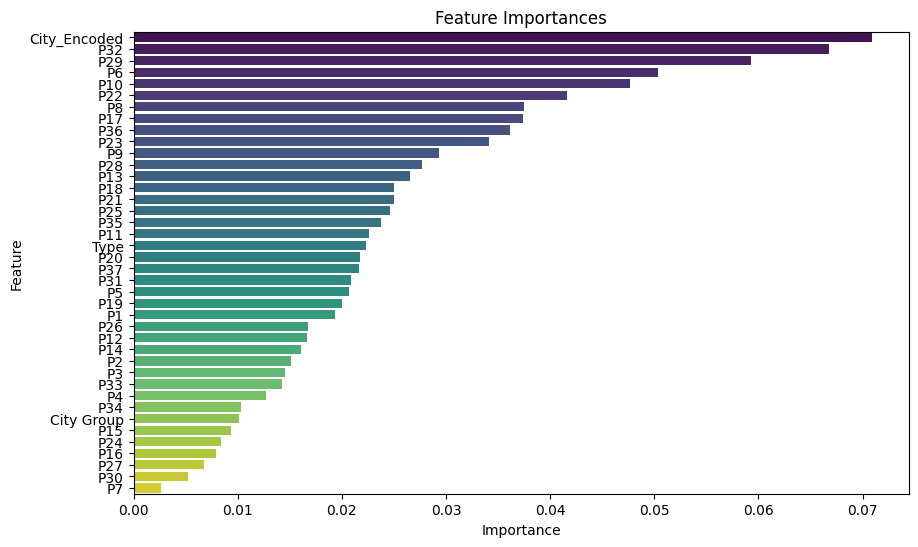

In [105]:
def feature_importances(X, model):

  importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
  }).sort_values(by='Importance', ascending=False)

  plt.figure(figsize=(10, 6))
  sns.barplot(
      data=importance_df,
      x='Importance',
      y='Feature',
      hue='Feature',
      palette='viridis',
      legend=False
  )
  plt.xlabel('Importance')
  plt.ylabel('Feature')
  plt.title('Feature Importances')
  plt.show()

feature_importances(X, model)

# Analisis II

**Anotacions**

1.   Uitilitzar la variable city fent target encoding es fer trampes, nomes es pot utilizar pels que hi ha suficient mostra (>5). Istanbul i Ankara, la resta missings

2.   No es pot fer target encoding de la variables Type perque tampoc hi ha mostra en tots els tipus. Missing pel cas DT i MB (test)

3.   Molts 0s de moltes de les varaibles, P14, P15, P16, P17, P18, P24 al P27, P30 al P37 --> No veig clar que es això. Al test aquestes variables tambe tenen molts 0. P32 sembla molt important al model i te molts 0s per exemple

4. Potser es important el temps que porta obert el local?

**Estrategia**
1.   Fittejar un segon model sense fer les trampes que he fet fins ara amb el target encoding.
2.   Buscar en quins casos m'allunyo més de la realitat.
3.   Les variables que ajuden poc cal manternirles?


In [106]:
def data_preparation2(df):
    df_train = df.copy()
    df_train['City Group'] = df_train['City Group'].astype('category').cat.codes

    city_stats = df_train.groupby('City')['revenue'].agg(['mean', 'count'])
    valid_city_means = city_stats['mean'].where(city_stats['count'] >= 5)
    df_train['City_Encoded'] = df_train['City'].map(valid_city_means)
    global_mean = df_train['revenue'].mean()
    df_train['City_Encoded'] = df_train['City_Encoded'].fillna(global_mean)

    type_mapping = {
          'FC': 2,
          'IL': 1,
          'DT': 0,
          'MB': 0}

    df_train['Type_Encoded'] = df_train['Type'].map(type_mapping)

    df_train['Open Date'] = pd.to_datetime(df['Open Date'])
    df_train['Year'] = df_train['Open Date'].dt.year
    df_train['Month'] = df_train['Open Date'].dt.month
    df_train['Days_Open'] = (pd.to_datetime('2015-01-01') - df_train['Open Date']).dt.days

    drop_cols = ['Id', 'Open Date', 'City', 'Type']
    df_train = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])
    return df_train

df_processed2 = data_preparation2(df)

X2 = df_processed2.drop(columns=['revenue'])
y2 = df_processed2['revenue']

model2 = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model2.fit(X2, y2)

y_pred2 = model2.predict(X2)
rmse2 = root_mean_squared_error(y2, y_pred2)

print(f"RMSE XGBoost II: {rmse2}")

RMSE XGBoost II: 682215.6355131773


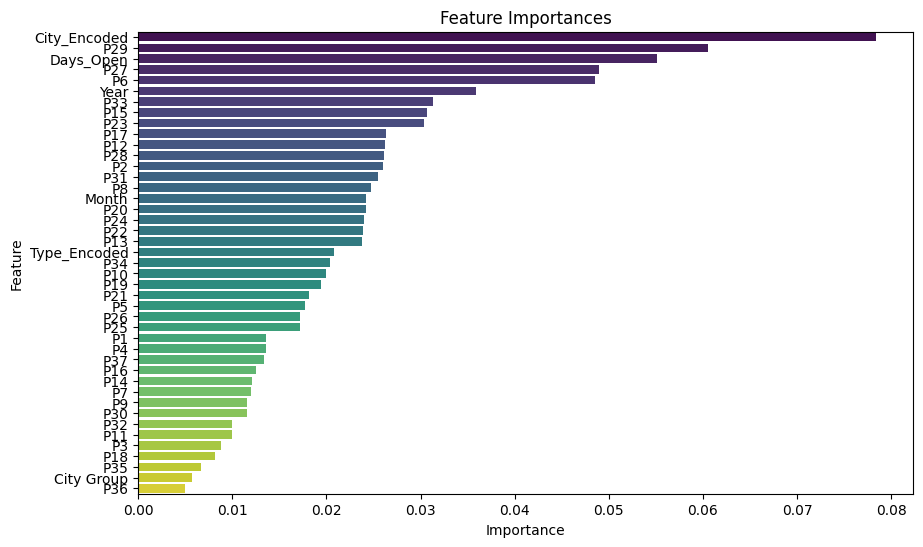

In [107]:
feature_importances(X2, model2)

In [108]:
pd.set_option('display.max_columns', None)
df_analysis = X2.copy()
df_analysis['revenue'] = y2
df_analysis['revenue_pred'] = y_pred2

df_analysis['abs_error'] = (df_analysis['revenue'] - df_analysis['revenue_pred']).abs()
df_analysis['squared_error'] = (df_analysis['revenue'] - df_analysis['revenue_pred']) ** 2

df_analysis = df_analysis.sort_values(by='abs_error', ascending=False)
df_analysis.head(10)

,City Group,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,City_Encoded,Type_Encoded,Year,Month,Days_Open,revenue,revenue_pred,abs_error,squared_error
16,0,3,5.0,4.0,4.0,2,5,5,4,5,4,3,5,4.0,0,0,0,0,0,1,4,1,1,1,0,0,0.0,0.0,2.0,2.0,0,0,0,0,0,0,0,0,5.577812e+06,2,2000,1,5473,19696939.0,16481743.0,3215196.0,1.033749e+13
100,0,3,5.0,4.0,4.0,2,5,5,5,5,5,2,5,5.0,0,0,0,0,0,4,5,2,2,1,0,0,0.0,0.0,4.0,3.0,0,0,0,0,0,0,0,0,5.577812e+06,2,2007,9,2659,9652350.0,7520846.0,2131504.0,4.543309e+12
116,0,2,4.0,4.0,4.0,2,2,5,4,4,5,3,4,5.0,0,0,0,0,0,2,2,1,1,1,0,0,0.0,0.0,3.0,3.0,0,0,0,0,0,0,0,0,5.287571e+06,2,2012,3,1007,8894598.0,6895880.0,1998718.0,3.994874e+12
85,0,3,5.0,4.0,4.0,2,5,5,4,5,4,3,5,4.0,0,0,0,0,0,1,4,1,1,1,0,0,0.0,0.0,2.0,3.0,0,0,0,0,0,0,0,0,5.577812e+06,2,2000,1,5473,7495092.0,9177906.0,1682814.0,2.831863e+12
48,1,4,5.0,4.0,4.0,2,2,5,4,4,5,4,4,5.0,0,0,0,0,0,5,5,3,3,5,0,0,0.0,0.0,4.0,3.0,0,0,0,0,0,0,0,0,4.453533e+06,2,2011,12,1107,7201784.0,5697388.0,1504396.0,2.263207e+12
75,0,5,5.0,4.0,5.0,1,4,5,3,4,4,5,3,4.0,0,0,0,0,0,5,5,5,5,4,0,0,0.0,0.0,5.0,0.0,0,0,0,0,0,0,0,0,5.577812e+06,2,2005,10,3365,16549064.0,15064317.0,1484747.0,2.204474e+12
49,0,12,7.5,6.0,6.0,2,8,10,10,10,10,4,10,7.5,0,0,0,0,0,15,3,3,3,5,0,0,0.0,0.0,7.5,7.5,0,0,0,0,0,0,0,0,5.577812e+06,2,2008,4,2466,8630682.0,7146977.5,1483704.5,2.201379e+12
127,1,3,4.0,4.0,4.0,2,2,5,5,5,5,1,5,5.0,0,0,0,0,0,3,2,1,2,1,0,0,0.0,0.0,3.0,3.0,0,0,0,0,0,0,0,0,4.092295e+06,2,2007,9,2673,7592272.0,6126460.5,1465811.5,2.148603e+12
66,1,2,2.0,4.0,3.0,1,1,1,4,5,5,3,5,5.0,0,0,0,0,0,4,3,1,1,2,0,0,0.0,0.0,2.0,3.0,0,0,0,0,0,0,0,0,4.453533e+06,2,2010,1,1818,1882131.0,3134867.5,1252736.5,1.569349e+12
17,0,2,4.0,4.0,5.0,1,3,5,4,5,5,3,5,5.0,0,0,0,0,0,1,1,1,1,1,0,0,0.0,0.0,1.0,1.0,0,0,0,0,0,0,0,0,5.577812e+06,2,2009,11,1880,8213524.0,6973417.0,1240107.0,1.537865e+12


In [109]:
df_analysis.tail(10)

,City Group,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,City_Encoded,Type_Encoded,Year,Month,Days_Open,revenue,revenue_pred,abs_error,squared_error
30,1,1,1.0,3.0,3.0,2,1,1,5,5,5,2,5,5.0,0,0,0,0,0,1,1,1,1,1,0,0,0.0,0.0,1.0,3.0,0,0,0,0,0,0,0,0,4.453533e+06,1,2008,12,2222,3008199.0,2962062.50,46136.50,2.128577e+09
2,1,2,4.0,2.0,5.0,2,3,5,5,5,5,2,5,5.0,0,0,0,0,0,1,1,1,1,1,0,0,0.0,0.0,1.0,3.0,0,0,0,0,0,0,0,0,4.453533e+06,1,2013,3,663,2055379.0,2095914.25,40535.25,1.643106e+09
41,0,4,5.0,5.0,4.0,1,5,5,3,4,5,5,3,5.0,3,4,5,5,4,5,5,5,5,5,5,3,5.0,1.0,5.0,1.0,5,5,4,3,3,4,4,1,5.577812e+06,1,2009,6,2040,4554237.0,4585231.50,30994.50,9.606590e+08
122,0,12,7.5,6.0,7.5,2,8,10,8,8,8,10,6,6.0,15,8,12,6,9,25,15,9,5,15,6,10,10.0,5.0,12.5,2.5,25,15,25,6,18,3,16,6,5.577812e+06,1,1997,4,6475,4286645.0,4311561.00,24916.00,6.208071e+08
124,0,1,3.0,0.0,5.0,5,5,1,5,5,5,2,5,5.0,0,0,0,0,0,1,2,2,1,2,0,0,0.0,0.0,2.0,3.0,0,0,0,0,0,0,0,0,3.275406e+06,0,2005,8,3423,3810007.0,3832629.25,22622.25,5.117662e+08
33,1,2,3.0,4.0,4.0,2,2,5,5,5,5,1,5,5.0,0,0,0,0,0,3,1,1,2,1,0,0,0.0,0.0,2.0,3.0,0,0,0,0,0,0,0,0,3.247870e+06,2,2013,4,618,2371202.0,2352120.75,19081.25,3.640941e+08
71,0,12,7.5,6.0,6.0,2,10,10,10,10,10,4,10,7.5,9,8,12,3,12,10,9,6,3,5,8,8,10.0,10.0,10.0,7.5,5,6,10,6,18,12,12,6,5.577812e+06,1,2006,12,2948,4136425.0,4153339.75,16914.75,2.861088e+08
46,0,3,5.0,5.0,3.0,1,2,5,5,5,5,2,5,5.0,2,2,4,2,4,2,5,2,4,2,1,1,1.0,4.0,3.0,3.0,5,5,4,2,2,4,3,3,5.287571e+06,1,2011,8,1225,4250758.0,4262188.50,11430.50,1.306563e+08
101,1,3,4.0,5.0,4.0,2,2,5,4,5,5,4,5,5.0,5,4,5,5,4,5,5,4,2,5,1,1,1.0,0.0,2.0,3.0,5,5,5,5,4,5,5,4,4.453533e+06,1,2012,9,844,4758476.0,4766449.50,7973.50,6.357670e+07
27,1,4,5.0,4.0,3.0,1,2,5,4,4,5,4,4,5.0,0,0,0,0,0,5,5,5,5,5,0,0,0.0,0.0,4.0,3.0,0,0,0,0,0,0,0,0,4.092295e+06,2,1999,10,5563,5435276.0,5432930.50,2345.50,5.501370e+06


# Analisis III

**Anotacions**

1.   Crec que ja no estic fent trampes amb Type ni amb City. City group no aporta --> Eliminar.

2.   El temps que el el local fa que esta obert es molt important. Es pot crear la mateixa variable al dataset de test. No entenc que captura Year, Month crec que s'hauria d'eliminar.

3.   Veig locals que tenen valors molt similars en tots els camps... 16 i 85 amb facturacions super diferents. Nomès tenen un camp de diferencia. Mirar si nhi ha més. Obertura el mateix dia... Com pot ser?

4.   Les millors prediccions son sobre Type = 1 i les pitjor sobre el 2.
5.   Potser hauria de probar un city endoded que no tingues en compte la facturació.

In [110]:
p_cols = [c for c in df.columns if c.startswith('P')]

matches = []
for i in range(len(df)):
    for j in range(i + 1, len(df)):
        same_count = (df.iloc[i][p_cols] == df.iloc[j][p_cols]).sum()
        if same_count >= 25:
            matches.append({
                'Fila_A': i,
                'Fila_B': j,
                'Campos_Iguales': same_count,
                'Total_Campos_P': len(p_cols)
            })

matches_df = pd.DataFrame(matches).sort_values(by='Campos_Iguales', ascending=False)
matches_df.head(20)

,Fila_A,Fila_B,Campos_Iguales,Total_Campos_P
309,16,38,37,37
826,38,85,36,37
1668,103,113,36,37
325,16,85,36,37
1082,55,128,35,37
1552,88,105,34,37
703,33,76,34,37
701,33,69,34,37
877,43,95,34,37
718,33,111,34,37


In [111]:
pd.set_option('display.max_columns', 32)
df.loc[[16,85,38]]

,Id,Open Date,City,City Group,Type,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,...,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,revenue
16,16,01/07/2000,İstanbul,Big Cities,FC,3,5.0,4.0,4.0,2,5,5,4,5,4,3,...,1,0,0,0.0,0.0,2.0,2.0,0,0,0,0,0,0,0,0,19696939.0
85,85,01/07/2000,İstanbul,Big Cities,FC,3,5.0,4.0,4.0,2,5,5,4,5,4,3,...,1,0,0,0.0,0.0,2.0,3.0,0,0,0,0,0,0,0,0,7495092.0
38,38,01/18/2011,İstanbul,Big Cities,FC,3,5.0,4.0,4.0,2,5,5,4,5,4,3,...,1,0,0,0.0,0.0,2.0,2.0,0,0,0,0,0,0,0,0,5461700.0


In [112]:
df.loc[[103,113]]

,Id,Open Date,City,City Group,Type,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,...,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,revenue
103,103,12/06/2011,Tekirdağ,Other,FC,2,4.0,4.0,4.0,1,2,5,5,5,5,2,...,1,0,0,0.0,0.0,2.0,2.0,0,0,0,0,0,0,0,0,4429512.0
113,113,12/09/2006,Tekirdağ,Other,FC,3,4.0,4.0,4.0,1,2,5,5,5,5,2,...,1,0,0,0.0,0.0,2.0,2.0,0,0,0,0,0,0,0,0,2097022.0


In [113]:
df.loc[[55,128]]

,Id,Open Date,City,City Group,Type,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,...,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,revenue
55,55,08/12/2008,İstanbul,Big Cities,FC,2,4.0,4.0,4.0,1,4,5,5,5,5,1,...,1,0,0,0.0,0.0,3.0,3.0,0,0,0,0,0,0,0,0,6941173.0
128,128,10/14/2011,Ankara,Big Cities,FC,2,4.0,4.0,4.0,1,2,5,5,5,5,1,...,1,0,0,0.0,0.0,3.0,2.0,0,0,0,0,0,0,0,0,2383840.0


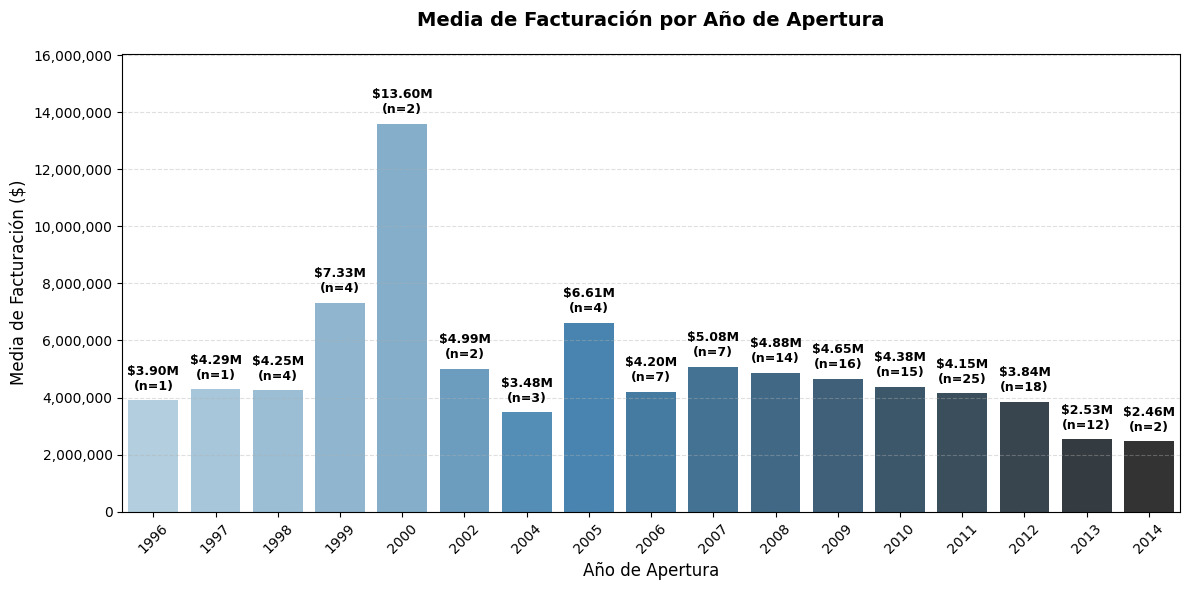

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar por año: calcular la media de facturación y la cantidad de locales
yearly_stats = df_processed2.groupby('Year')['revenue'].agg(['mean', 'count']).reset_index()

# 2. Configurar el tamaño y estilo de la gráfica
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=yearly_stats,
    x='Year',
    y='mean',
    hue='Year',
    palette='Blues_d',
    legend=False
)

# 3. Personalizar títulos y ejes
plt.title('Media de Facturación por Año de Apertura', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Año de Apertura', fontsize=12)
plt.ylabel('Media de Facturación ($)', fontsize=12)

# Formatear el eje Y con separadores de miles
ax.yaxis.set_major_formatter('{x:,.0f}')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 4. Agregar el valor de la media y el conteo de locales encima de cada barra
for index, row in yearly_stats.iterrows():
    val_str = f"${row['mean']/1e6:.2f}M\n(n={int(row['count'])})"
    ax.text(
        index,
        row['mean'] + (yearly_stats['mean'].max() * 0.02),
        val_str,
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Ajustar límite superior del eje Y para que no se corten las etiquetas
plt.ylim(0, yearly_stats['mean'].max() * 1.18)

plt.tight_layout()
plt.show()

In [115]:
df_processed2[df_processed2['Year']== 2000]

,City Group,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,...,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,revenue,City_Encoded,Type_Encoded,Year,Month,Days_Open
16,0,3,5.0,4.0,4.0,2,5,5,4,5,4,3,5,4.0,0,0,...,2.0,2.0,0,0,0,0,0,0,0,0,19696939.0,5577811.96,2,2000,1,5473
85,0,3,5.0,4.0,4.0,2,5,5,4,5,4,3,5,4.0,0,0,...,2.0,3.0,0,0,0,0,0,0,0,0,7495092.0,5577811.96,2,2000,1,5473


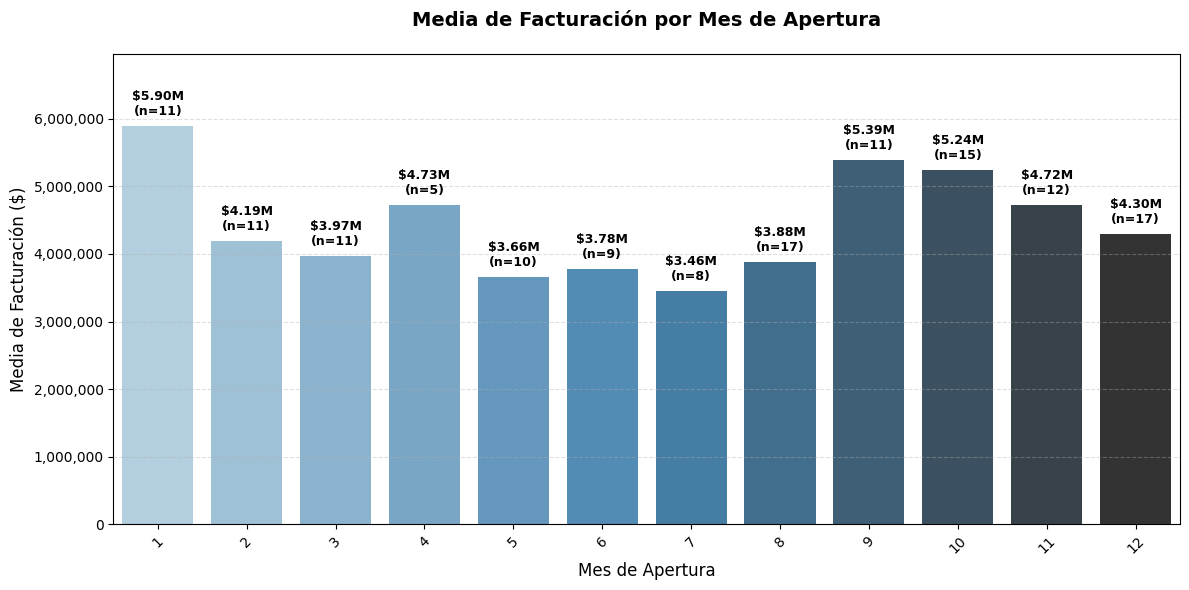

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar por año: calcular la media de facturación y la cantidad de locales
month_stats = df_processed2.groupby('Month')['revenue'].agg(['mean', 'count']).reset_index()

# 2. Configurar el tamaño y estilo de la gráfica
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=month_stats,
    x='Month',
    y='mean',
    hue='Month',
    palette='Blues_d',
    legend=False
)

# 3. Personalizar títulos y ejes
plt.title('Media de Facturación por Mes de Apertura', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mes de Apertura', fontsize=12)
plt.ylabel('Media de Facturación ($)', fontsize=12)

# Formatear el eje Y con separadores de miles
ax.yaxis.set_major_formatter('{x:,.0f}')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 4. Agregar el valor de la media y el conteo de locales encima de cada barra
for index, row in month_stats.iterrows():
    val_str = f"${row['mean']/1e6:.2f}M\n(n={int(row['count'])})"
    ax.text(
        index,
        row['mean'] + (month_stats['mean'].max() * 0.02),
        val_str,
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Ajustar límite superior del eje Y para que no se corten las etiquetas
plt.ylim(0, month_stats['mean'].max() * 1.18)

plt.tight_layout()
plt.show()

# Analisis IV

**Anotacions**

1.   Crec que hi ha evidencia suficient per eliminar el Id = 16 del dataset, s'hauria de confirmar amb la persona que genera les dades però presenta valors no nomes repetits, sinó anomals en termes de facturació.


5.   Potser hauria de probar un city encoded que no tingues en compte la facturació.

**Estrategia**
1. Eliminar el 16 de la mostra.
2. Entrenar el model amb cross validation i fer feature selecction.
3.

In [117]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold

def data_preparation3(df):
    df_train = df[df['Id'] != 16].copy()

    df_train['City Group'] = df_train['City Group'].astype('category').cat.codes

    city_stats = df_train.groupby('City')['revenue'].agg(['mean', 'count'])
    valid_city_means = city_stats['mean'].where(city_stats['count'] >= 5)
    df_train['City_Encoded'] = df_train['City'].map(valid_city_means)
    global_mean = df_train['revenue'].mean()
    df_train['City_Encoded'] = df_train['City_Encoded'].fillna(global_mean)

    frequent_cities = city_stats[city_stats['count'] >= 5].index
    city_mapping = {city: idx + 1 for idx, city in enumerate(frequent_cities)}
    df_train['City_Group_Ordinal'] = df_train['City'].map(city_mapping).fillna(0).astype(int)

    type_mapping = {
        'FC': 2,
        'IL': 1,
        'DT': 0,
        'MB': 0
    }
    df_train['Type_Encoded'] = df_train['Type'].map(type_mapping)

    df_train['Open Date'] = pd.to_datetime(df_train['Open Date'])
    df_train['Year'] = df_train['Open Date'].dt.year
    df_train['Month'] = df_train['Open Date'].dt.month
    df_train['Days_Open'] = (pd.to_datetime('2015-01-01') - df_train['Open Date']).dt.days

    drop_cols = ['Id', 'Open Date', 'City', 'Type']
    df_train = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])

    return df_train

df_processed3 = data_preparation3(df)

X3 = df_processed3.drop(columns=['revenue', 'Month', 'City_Group_Ordinal'])
y3 = df_processed3['revenue']

model3 = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 5. Feature Selection mediante RFECV (Cross-Validation)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

selector = RFECV(
    estimator=model3,
    step=1,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    min_features_to_select=5
)

selector.fit(X3, y3)

selected_features = list(X3.columns[selector.support_])
X3_selected = X3[selected_features]

print(f"Número total de variables iniciales: {X3.shape[1]}")
print(f"Número de variables seleccionadas por RFECV: {len(selected_features)}")
print("\nVariables seleccionadas:")
print(selected_features)

model3.fit(X3_selected, y3)

y_pred3 = model3.predict(X3_selected)
rmse3 = root_mean_squared_error(y3, y_pred3)

print(f"\nRMSE XGBoost III (In-Sample): {rmse3:,.2f}")

Número total de variables iniciales: 42
Número de variables seleccionadas por RFECV: 38

Variables seleccionadas:
['City Group', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12', 'P13', 'P14', 'P16', 'P17', 'P18', 'P19', 'P20', 'P21', 'P22', 'P23', 'P25', 'P26', 'P27', 'P28', 'P29', 'P31', 'P32', 'P34', 'P35', 'P36', 'P37', 'City_Encoded', 'Type_Encoded', 'Year', 'Days_Open']

RMSE XGBoost III (In-Sample): 684,754.28


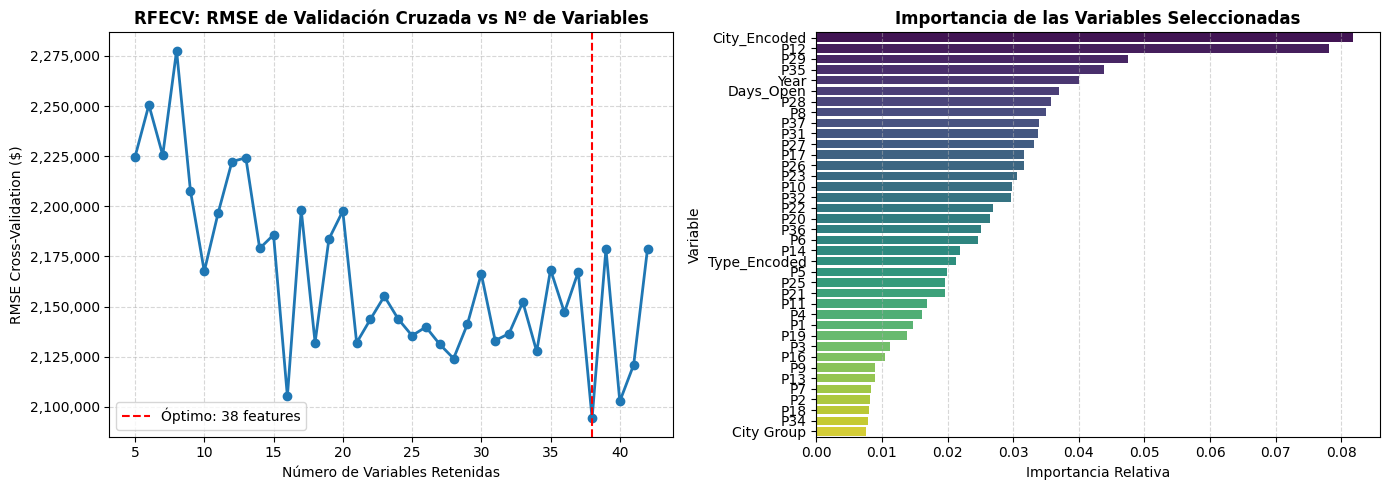

In [118]:
n_features_range = range(
    selector.min_features_to_select,
    X3.shape[1] + 1,
    selector.step)

if hasattr(selector, 'cv_results_'):
    mean_rmse_scores = -selector.cv_results_['mean_test_score']
else:
    mean_rmse_scores = -selector.grid_scores_

plt.figure(figsize=(14, 5))

# Subplot 1: Curva de RFECV
plt.subplot(1, 2, 1)
plt.plot(n_features_range, mean_rmse_scores, marker='o', color='#1f77b4', linewidth=2)
plt.axvline(
    x=len(selected_features),
    color='red',
    linestyle='--',
    label=f'Óptimo: {len(selected_features)} features'
)
plt.title('RFECV: RMSE de Validación Cruzada vs Nº de Variables', fontsize=12, fontweight='bold')
plt.xlabel('Número de Variables Retenidas', fontsize=10)
plt.ylabel('RMSE Cross-Validation ($)', fontsize=10)
plt.gca().yaxis.set_major_formatter('{x:,.0f}')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Subplot 2: Importancia de las variables seleccionadas
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': model3.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.subplot(1, 2, 2)
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('Importancia de las Variables Seleccionadas', fontsize=12, fontweight='bold')
plt.xlabel('Importancia Relativa', fontsize=10)
plt.ylabel('Variable', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Entrenar**

1. Un model amb 38 variables i busqueda de hiperparàmetres
2. Un model amb 16 variables i busqueda de hiperparàmetres

3. Comparar models

Buscando hiperparámetros óptimos para el Modelo 10 features...
Buscando hiperparámetros óptimos para el Modelo 15 features...
Buscando hiperparámetros óptimos para el Modelo 38 features...

 RESULTADOS DEFINITIVOS (5-FOLD CROSS-VALIDATION) 
MODELO 1 (15 Variables):
  -> RMSE CV Medio : $1,971,838.04 (+/- $544,091.14)
  -> Hiperparámetros óptimos: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 150, 'subsample': 0.6}
-----------------------------------------------------------------
MODELO 2 (38 Variables):
  -> RMSE CV Medio : $1,961,264.94 (+/- $559,981.63)
  -> Hiperparámetros óptimos: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.6}
MODELO 3 (10 Variables):
  -> RMSE CV Medio : $1,956,969.99 (+/- $486,961.90)
  -> Hiperparámetros óptimos: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 50, 'subsample': 0.8}
------------------------------------------------------------

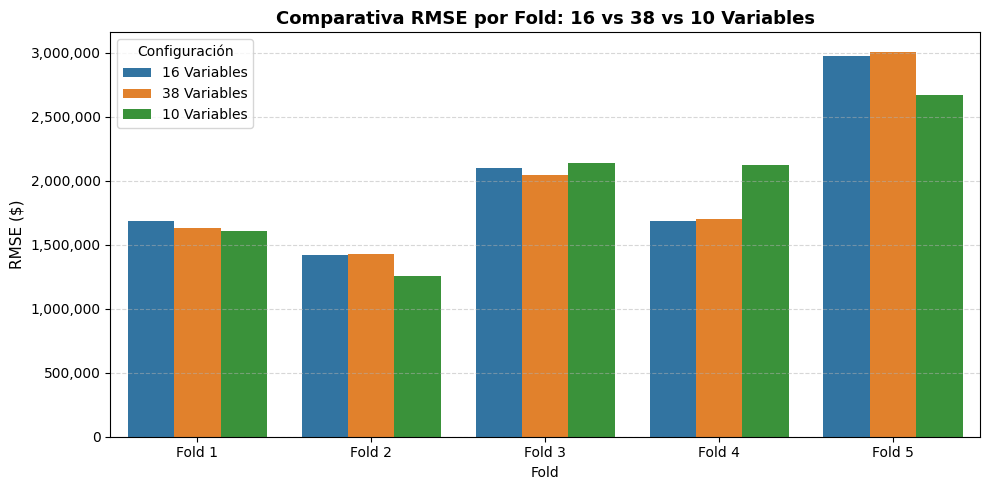

In [119]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

df_processed4 = data_preparation3(df)

X4 = df_processed4.drop(columns=['revenue', 'Month', 'City_Group_Ordinal'])
y4 = df_processed4['revenue']

feature_importances = pd.Series(model3.feature_importances_, index=X3_selected.columns)
sorted_features = feature_importances.sort_values(ascending=False).index.tolist()

features_10 = sorted_features[:10]
features_16 = sorted_features[:16]
features_38 = sorted_features[:38]

X_10 = X4[features_10]
X_16 = X4[features_16]
X_38 = X4[features_38]

# 3. Definir la rejilla de hiperparámetros para la búsqueda (GridSearch)
param_grid = {
    'n_estimators': [25, 50, 100, 150],
    'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8]
}

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

def optimize_xgb(X_data, y_data):
    grid = GridSearchCV(
        estimator=xgb.XGBRegressor(random_state=42),
        param_grid=param_grid,
        cv=cv_strategy,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    grid.fit(X_data, y_data)
    return grid.best_estimator_, grid.best_params_

print("Buscando hiperparámetros óptimos para el Modelo 10 features...")
model_10, params_10 = optimize_xgb(X_10, y4)

print("Buscando hiperparámetros óptimos para el Modelo 15 features...")
model_16, params_16 = optimize_xgb(X_16, y4)

print("Buscando hiperparámetros óptimos para el Modelo 38 features...")
model_38, params_38 = optimize_xgb(X_38, y4)

# 4. Evaluación mediante 5-Fold Cross-Validation en ambos modelos definitivos
scores_10 = cross_val_score(model_10, X_10, y4, cv=cv_strategy, scoring='neg_root_mean_squared_error')
scores_16 = cross_val_score(model_16, X_16, y4, cv=cv_strategy, scoring='neg_root_mean_squared_error')
scores_38 = cross_val_score(model_38, X_38, y4, cv=cv_strategy, scoring='neg_root_mean_squared_error')

rmse_cv_10 = -scores_10.mean()
std_cv_10 = scores_10.std()

rmse_cv_16 = -scores_16.mean()
std_cv_16 = scores_16.std()

rmse_cv_38 = -scores_38.mean()
std_cv_38 = scores_38.std()

# 5. Imprimir resultados comparativos
print("\n" + "=" * 65)
print(" RESULTADOS DEFINITIVOS (5-FOLD CROSS-VALIDATION) ")
print("=" * 65)
print(f"MODELO 1 (15 Variables):")
print(f"  -> RMSE CV Medio : ${rmse_cv_16:,.2f} (+/- ${std_cv_16:,.2f})")
print(f"  -> Hiperparámetros óptimos: {params_16}")
print("-" * 65)
print(f"MODELO 2 (38 Variables):")
print(f"  -> RMSE CV Medio : ${rmse_cv_38:,.2f} (+/- ${std_cv_38:,.2f})")
print(f"  -> Hiperparámetros óptimos: {params_38}")
print("=" * 65)
print(f"MODELO 3 (10 Variables):")
print(f"  -> RMSE CV Medio : ${rmse_cv_10:,.2f} (+/- ${std_cv_10:,.2f})")
print(f"  -> Hiperparámetros óptimos: {params_10}")
print("-" * 65)

# 6. Gráfico comparativo de rendimiento (Fold a Fold)
fold_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)] * 3,
    'RMSE': list(-scores_16) + list(-scores_38) + list(-scores_10),
    'Modelo': ['16 Variables'] * 5 + ['38 Variables'] * 5  + ['10 Variables'] * 5
})

plt.figure(figsize=(10, 5))
sns.barplot(data=fold_df, x='Fold', y='RMSE', hue='Modelo', palette=['#1f77b4', '#ff7f0e' , '#2ca02c'])
plt.title('Comparativa RMSE por Fold: 16 vs 38 vs 10 Variables', fontsize=13, fontweight='bold')
plt.ylabel('RMSE ($)', fontsize=11)
plt.gca().yaxis.set_major_formatter('{x:,.0f}')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Configuración')
plt.tight_layout()
plt.show()

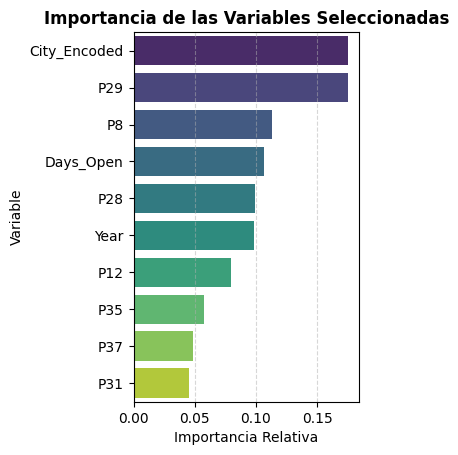

In [120]:
# feature_importances(X_10, model_10)

importance_df = pd.DataFrame({
    'Feature': X_10.columns,
    'Importance': model_10.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.subplot(1, 2, 2)
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('Importancia de las Variables Seleccionadas', fontsize=12, fontweight='bold')
plt.xlabel('Importancia Relativa', fontsize=10)
plt.ylabel('Variable', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
# plt.tight_layout()
plt.show()


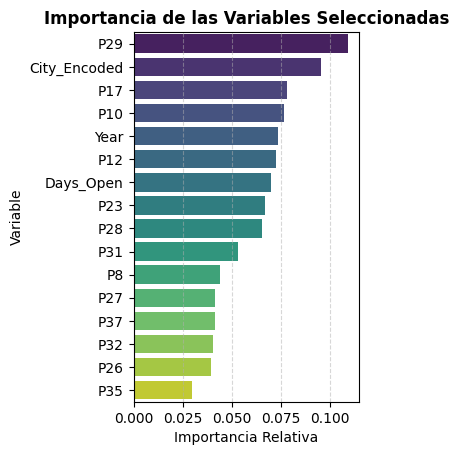

In [121]:
importance_df = pd.DataFrame({
    'Feature': X_16.columns,
    'Importance': model_16.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.subplot(1, 2, 2)
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('Importancia de las Variables Seleccionadas', fontsize=12, fontweight='bold')
plt.xlabel('Importancia Relativa', fontsize=10)
plt.ylabel('Variable', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
# plt.tight_layout()
plt.show()


# Final model

In [122]:
# =========================================================================
# 7. ENTRENAMIENTO DEL MODELO FINAL DE XGBOOST (100% DATASET)
# =========================================================================

# 1. Forzamos de forma segura a que use exactamente las 16 variables del subset
# (Nota: En Python seleccionamos [:16] para obtener las primeras 16 de la lista indexada)
features_finales = sorted_features[:16]
X_final = X4[features_finales]

# 2. Definimos los hiperparámetros óptimos ganadores que indicaste
mejores_parametros = {
    'colsample_bytree': 0.7,
    'learning_rate': 0.01,
    'max_depth': 3,
    'n_estimators': 150,
    'subsample': 0.6,
    'random_state': 42  # Mantenemos la semilla para asegurar reproducibilidad
}

# 3. Instanciamos el regresor final
final_xgb_model = xgb.XGBRegressor(**mejores_parametros)

# 4. ENTRENAMIENTO DEFINITIVO: El modelo consume absolutamente todas las filas
final_xgb_model.fit(X_final, y4)

print("=" * 65)
print(" 🚀 ¡MODELO FINAL DE XGBOOST ENTRENADO CON ÉXITO! ")
print("=" * 65)
print(f"Número de variables utilizadas: {len(features_finales)}")
print(f"Hiperparámetros aplicados: {mejores_parametros}")

# 5. Evaluación In-Sample (Para verificar cómo se ajusta a los datos de entrenamiento)
y_pred_final = final_xgb_model.predict(X_final)
rmse_in_sample = root_mean_squared_error(y4, y_pred_final)
print(f"-> RMSE Final In-Sample (Sobre los datos de entrenamiento): ${rmse_in_sample:,.2f}")
print("=" * 65)


 🚀 ¡MODELO FINAL DE XGBOOST ENTRENADO CON ÉXITO! 
Número de variables utilizadas: 16
Hiperparámetros aplicados: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 150, 'subsample': 0.6, 'random_state': 42}
-> RMSE Final In-Sample (Sobre los datos de entrenamiento): $1,631,488.25


In [123]:
mean_revenue = df_processed2['revenue'].agg(['mean']).reset_index()
mean_revenue

,index,revenue
0,mean,4.453533e+06


## Catboost?

In [124]:
!pip install catboost

In [125]:
import numpy as np
import pandas as pd
import catboost as cb
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from category_encoders import TargetEncoder

def data_preparation_clean(df):
    df_train = df[df['Id'] != 16].copy()

    # Mantenemos las categorías como texto (se codificarán dentro del bucle de CV)
    df_train['City Group'] = df_train['City Group'].astype(str)
    df_train['City'] = df_train['City'].astype(str)
    df_train['Type'] = df_train['Type'].astype(str)

    # Procesamiento de fechas básico
    df_train['Open Date'] = pd.to_datetime(df_train['Open Date'])
    df_train['Year'] = df_train['Open Date'].dt.year
    df_train['Days_Open'] = (pd.to_datetime('2015-01-01') - df_train['Open Date']).dt.days

    # Eliminamos IDs, fechas y Month (que ya decidiste quitar)
    drop_cols = ['Id', 'Open Date', 'Month']
    df_train = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])

    return df_train

# 1. Procesar datos
df_processed3 = data_preparation_clean(df)
X3 = df_processed3.drop(columns=['revenue'])
y3 = df_processed3['revenue']

cat_features = ['City', 'City Group', 'Type']

# =========================================================================
# 🔥 ELIMINACIÓN RECURSIVA DE VARIABLES (RFE) MANUAL CON CROSS-VALIDATION
# =========================================================================
# Reemplaza a RFECV para evitar el bug de conversión a float de scikit-learn.
# Garantiza CERO DATA LEAKAGE codificando las categorías por cada fold.

cv = KFold(n_splits=5, shuffle=True, random_state=42)
min_features_to_select = 5

features_actuales = list(X3.columns)
historial_features = []
historial_rmse = []

print("Iniciando selección de variables (RFE Manual)...")

while len(features_actuales) >= min_features_to_select:
    cv_scores = []

    # Evaluar el conjunto actual de variables usando 5-Fold Cross Validation
    for train_idx, val_idx in cv.split(X3, y3):
        # Separar pliegues de entrenamiento y validación
        X_train, X_val = X3.iloc[train_idx][features_actuales], X3.iloc[val_idx][features_actuales]
        y_train, y_val = y3.iloc[train_idx], y3.iloc[val_idx]

        # Identificar qué variables categóricas siguen presentes
        cat_en_fold = [col for col in cat_features if col in features_actuales]

        # Target Encoding exclusivo con los datos de ENTRENAMIENTO del fold (Evita Overfitting)
        encoder = TargetEncoder(cols=cat_en_fold, smoothing=20.0)
        X_train_enc = encoder.fit_transform(X_train, y_train)
        X_val_enc = encoder.transform(X_val)

        # Definir y entrenar el modelo CatBoost en el fold
        model_fold = cb.CatBoostRegressor(
            iterations=80, learning_rate=0.03, depth=3, l2_leaf_reg=5, random_seed=42, verbose=0
        )
        model_fold.fit(X_train_enc, y_train)

        # Predecir en validación y guardar RMSE
        preds = model_fold.predict(X_val_enc)
        rmse_fold = root_mean_squared_error(y_val, preds)
        cv_scores.append(rmse_fold)

    # Calcular el RMSE promedio de la validación cruzada para esta combinación
    mean_rmse = np.mean(cv_scores)
    historial_features.append(list(features_actuales))
    historial_rmse.append(mean_rmse)

    # --- PASO DE ELIMINACIÓN ---
    # Si ya alcanzamos el mínimo, terminamos el bucle
    if len(features_actuales) == min_features_to_select:
        break

    # Para saber qué variable eliminar, entrenamos un modelo con TODO el set actual codificado
    cat_global = [col for col in cat_features if col in features_actuales]
    encoder_global = TargetEncoder(cols=cat_global, smoothing=20.0)
    X_enc_global = encoder_global.fit_transform(X3[features_actuales], y3)

    model_global = cb.CatBoostRegressor(
        iterations=80, learning_rate=0.03, depth=3, l2_leaf_reg=5, random_seed=42, verbose=0
    )
    model_global.fit(X_enc_global, y3)

    # Encontrar la variable menos importante (menor feature importance)
    importances = model_global.get_feature_importance()
    peor_feature_idx = np.argmin(importances)
    peor_feature = features_actuales[peor_feature_idx]

    # Eliminar la peor variable para la siguiente iteración
    features_actuales.remove(peor_feature)

# =========================================================================
# 2. IDENTIFICAR EL NÚMERO ÓPTIMO DE VARIABLES
# =========================================================================
# Buscamos el índice donde el RMSE de Cross-Validation fue el más bajo
idx_optimo = np.argmin(historial_rmse)
selected_features = historial_features[idx_optimo]

print(f"\n¡Selección completada!")
print(f"Número total de variables iniciales: {X3.shape[1]}")
print(f"Número óptimo de variables seleccionadas: {len(selected_features)}")
print("\nVariables seleccionadas recomendadas:")
print(selected_features)

# =========================================================================
# 3. ENTRENAMIENTO DEL MODELO FINAL (Con todo el dataset)
# =========================================================================
X3_selected = X3[selected_features]
cat_features_final = [col for col in cat_features if col in selected_features]

# Codificación final
final_encoder = TargetEncoder(cols=cat_features_final, smoothing=20.0)
X3_final_encoded = final_encoder.fit_transform(X3_selected, y3)

# Modelo final entrenado al 100%
final_model = cb.CatBoostRegressor(
    iterations=80, learning_rate=0.03, depth=3, l2_leaf_reg=5, random_seed=42, verbose=0
)
final_model.fit(X3_final_encoded, y3)

# Evaluación In-Sample
y_pred3 = final_model.predict(X3_final_encoded)
rmse_final = root_mean_squared_error(y3, y_pred3)
print(f"\nRMSE CatBoost Final (In-Sample): {rmse_final:,.2f}")


Iniciando selección de variables (RFE Manual)...

¡Selección completada!
Número total de variables iniciales: 42
Número óptimo de variables seleccionadas: 5

Variables seleccionadas recomendadas:
['City', 'P12', 'P28', 'Year', 'Days_Open']

RMSE CatBoost Final (In-Sample): 1,746,466.61


In [126]:
# ==========================================
# 1. PREPARACIÓN DE DATOS PARA EL GRÁFICO
# ==========================================

# Rango de variables evaluadas por el selector
n_features_range = range(
    selector.min_features_to_select,
    X3.shape[1] + 1,
    selector.step
)

# Extraer los scores de RMSE correctamente (compatible con versiones nuevas y antiguas de sklearn)
if hasattr(selector, 'cv_results_'):
    mean_rmse_scores = -selector.cv_results_['mean_test_score']
else:
    mean_rmse_scores = -selector.grid_scores_

# ==========================================
# 2. PROCESAMIENTO DE IMPORTANCIAS (CatBoost)
# ==========================================
# CatBoost calcula las importancias en el entrenamiento final con model3.fit(X3_selected, y3)
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': model3.get_feature_importance() # Método nativo de CatBoost más preciso
}).sort_values(by='Importance', ascending=False)


# ==========================================
# 3. GENERACIÓN DE LOS GRÁFICOS
# ==========================================
plt.figure(figsize=(14, 5))

# Subplot 1: Curva de RFECV
plt.subplot(1, 2, 1)
plt.plot(n_features_range, mean_rmse_scores, marker='o', color='#1f77b4', linewidth=2)
plt.axvline(
    x=len(selected_features),
    color='red',
    linestyle='--',
    label=f'Óptimo: {len(selected_features)} features'
)
plt.title('RFECV: RMSE de Validación Cruzada vs Nº de Variables', fontsize=12, fontweight='bold')
plt.xlabel('Número de Variables Retenidas', fontsize=10)
plt.ylabel('RMSE Cross-Validation ($)', fontsize=10)
plt.gca().yaxis.set_major_formatter('{x:,.0f}')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Subplot 2: Importancia de las variables seleccionadas (Adaptado a CatBoost)
plt.subplot(1, 2, 2)
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('Importancia de las Variables Seleccionadas (CatBoost)', fontsize=12, fontweight='bold')
plt.xlabel('Importancia Relativa (PredictionValuesChange)', fontsize=10)
plt.ylabel('Variable', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


AttributeError: 'XGBRegressor' object has no attribute 'get_feature_importance'